In [1]:
import numpy as np #Calculos
import pandas as pd #Dataframes
import seaborn as sns #Gráficos
import matplotlib.pyplot as plt #Gráficos

pinwinos = pd.read_csv('PinwinosPalmerLimpia.csv')
pinwinos.head()

,Especie,Isla,Sexo,Anio,Longitud_Pico_cm,Profundidad_Pico_cm,Longitud_Aleta_cm,Masa_Corporal_kg
0,Adelie,Torgersen,Macho,2007,3.91,1.87,18.1,3.75
1,Adelie,Torgersen,Hembra,2007,3.95,1.74,18.6,3.80
2,Adelie,Torgersen,Hembra,2007,4.03,1.80,19.5,3.25
3,Adelie,Torgersen,Hembra,2007,3.88,1.83,19.0,3.70
4,Adelie,Torgersen,Hembra,2007,3.67,1.93,19.3,3.45


# Modelos Lineales



In [2]:
# Modelos Linenales
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, Lasso, Ridge, LinearRegression
)
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error
)
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

#Semilla fija
np.random.seed(42)

In [3]:
#Features son las variables predictoras (medidas corporales)
FEATURES = ["Longitud_Pico_cm", "Profundidad_Pico_cm", "Longitud_Aleta_cm", "Masa_Corporal_kg"]

X = pinwinos[FEATURES].values #Matriz de predictores

In [4]:
#Clasificación de especie en números
le = LabelEncoder()
y = le.fit_transform(pinwinos["Especie"])
clases = le.classes_
print(f"Especies codificadas: {dict(zip(clases, range(len(clases))))}")
print(f"Total pingüinos: {len(pinwinos)}")

Especies codificadas: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
Total pingüinos: 344


In [5]:
#Definimos la cantidad de datos en un conjunto de entrenamiento y conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y #Se tomó 20% de datos de prueba con 80% de entrenamiento
)

#Escala y ajuste
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train) #Entrenamiento
X_test_sc = scaler.transform(X_test) #Prueba

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 275 | Test: 69


## Modelo Baseline

Se construyó un modelo baseline tomando como referencia la clase mayoritaria en el conjunto de entrenamiento. En este caso, corresponde a la especie de pingüino más frecuente; el modelo asigna a todas las observaciones la especie más frecuente al conjunto de entrenamiento.
Este modelo no utiliza variables predictoras y representa el desempeño mínimo que debe superarse, su exactitud corresponde a la proporción de la clase dominante y sirve como punto de referencia para evaluar la capacidad predictiva de los modelos posteriores

********************
  1. Baseline
********************
Especie mayoritaria: Adelie
Accuracy baseline: 0.4348
F1-macro: 0.2020
Recall-macro: 0.3333
Support por clase: {'Adelie': np.int64(30), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(25)}
Accuracy (CV-5): 0.4436




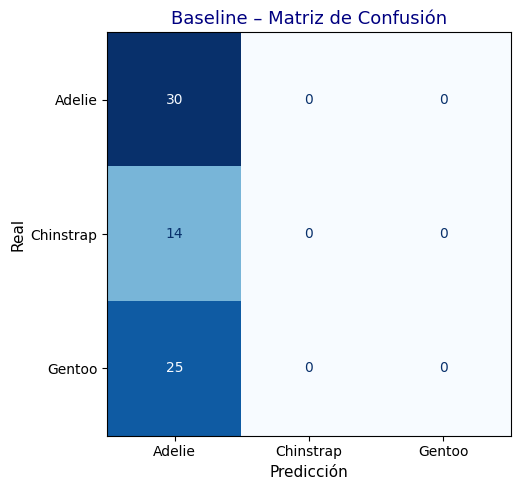

In [6]:
# 1. Baseline

print("*"*20)
print("  1. Baseline")
print("*"*20)

from sklearn.dummy import DummyClassifier

clase_may = np.bincount(y_train).argmax() #Especie más frecuente
y_baseline = np.full(len(y_test), clase_may) #Vector de predicciones
acc_base = accuracy_score(y_test, y_baseline) #Proporcion clasificada correctamente

#Versión como estimador real para poder usar cross_val_score
baseline_clf = DummyClassifier(strategy="most_frequent", random_state=42)
cv_base = cross_val_score(baseline_clf, X_train_sc, y_train, cv=5, scoring="accuracy").mean()

#Evaluación de modelo
print(f"Especie mayoritaria: {clases[clase_may]}")
print(f"Accuracy baseline: {acc_base:.4f}")
f1_macro = f1_score(y_test, y_baseline, average="macro")
print("F1-macro:", format(f1_macro, ".4f"))
recall_macro_base = recall_score(y_test, y_baseline, average="macro")
support_base = pd.Series(y_test).value_counts().reindex(range(len(clases))).values
print("Recall-macro:", format(recall_macro_base, ".4f"))
print("Support por clase:", dict(zip(clases, support_base)))
print(f"Accuracy (CV-5): {cv_base:.4f}")
print("\n")

#Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_baseline,
    display_labels=clases,
    ax=ax,
    colorbar=False,
    cmap="Blues"
)
ax.set_title("Baseline – Matriz de Confusión", fontsize=13, color = "navy")
ax.set_xlabel("Predicción", fontsize=11)
ax.set_ylabel("Real", fontsize=11)

plt.tight_layout()
plt.savefig("01_Matriz_Baseline.png", dpi=150)
plt.show()
plt.close()

La matriz de confusión muestra claramente de forma gráfica cómo el modelo clasifica a todas las observaciones como pertenecientes a la especie Adelie. Al obtener un accuracy del 43.48%, lo que equivale que 4 de 10 pingüinos serán clasificados correctamente únicamente por pertenecer a la clase más frecuente.

El indicador F1-score macro es muy bajo, evidenciado que el modelo baseline tiene un desempeño deficiente al no lograr identificar correctamente las especies Chinstrap y Gentoo, es por eso que la distribución de clases por sí sola no es suficiente para resolver el problema de clasificación, ya que el modelo ignora completamente la información contenida en las variables morfológicas.

## Modelo Regresión Logística

La Regresión Logística es un modelo estadístico que se utiliza para problemas de clasificación. Su esencia es estimar probabilidades de pertenencia a cada clase en función de las variables predictoras, este modelo aprovecha las variables morfológicas de los pingüinos para estimar la probabilidad de pertenencia a cada especie; aprende la relación entre las características físicas y la especie observada.

El enfoque probabilístico permite no solo generar una predicción de clase, sino también cuantificar la incertidumbre asociada a cada decisión, lo que resulta especialmente útil en problemas de clasificación multiclase, de esta manera, el modelo no se limita a dar una respuesta categórica, sino que ofrece una distribución de probabilidades entre las distintas especies, mostrando qué tan segura es cada decisión.

Los coeficientesbrindan una interpretación directa sobre la influencia de cada variable en la clasificación, un coeficiente *positivo* indica que al aumentar esa característica, crece la probabilidad de pertenecer a una especie determinada; mientras que un coeficiente *negativo* señala que el incremento de esa variable reduce dicha probabilidad.

******************************
  2. Regresión Ligística
******************************
Accuracy RL: 1.0000
F1-macro RL: 1.0000
Recall-macro RL: 1.0000
Support por clase RL: {'Adelie': np.int64(30), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(25)}
Accuracy (CV-5): 0.9855


Coeficientes por especie:
           Longitud_Pico_cm  Profundidad_Pico_cm  Longitud_Aleta_cm  Masa_Corporal_kg
Adelie               -2.576                1.451             -0.582             0.424
Chinstrap             2.190                0.266             -0.602            -1.434
Gentoo                0.386               -1.717              1.183             1.010




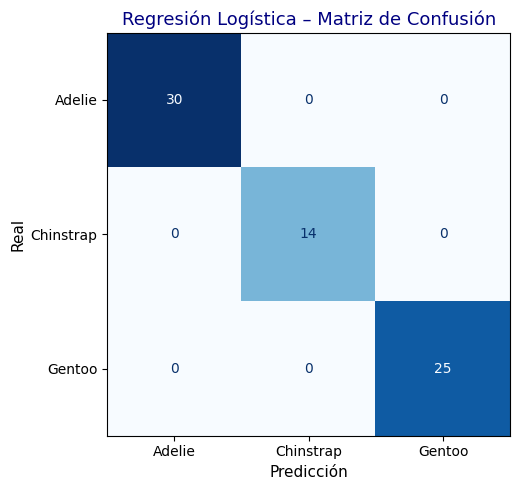

In [7]:
# 2. Regresión Ligística

print("*"*30)
print("  2. Regresión Ligística")
print("*"*30)

lr = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs") #Clasificador con 1000 iteraciones
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average="macro")
recall_lr = recall_score(y_test, y_pred_lr, average="macro") #Sensibilidad promedio por clase
support_lr = pd.Series(y_test).value_counts().reindex(range(len(clases))).values #Cantidad real de obs. por clase en test
cv_lr  = cross_val_score(lr, X_train_sc, y_train, cv=5, scoring="accuracy").mean()

#Evaluación de modelo
print(f"Accuracy RL: {acc_lr:.4f}")
print(f"F1-macro RL: {f1_lr:.4f}")
print(f"Recall-macro RL: {recall_lr:.4f}")
print(f"Support por clase RL: {dict(zip(clases, support_lr))}")
print(f"Accuracy (CV-5): {cv_lr:.4f}")

#Coeficientes
print("\n")
print("Coeficientes por especie:")
print(pd.DataFrame(lr.coef_, columns=FEATURES, index=clases).round(3).to_string())
print("\n")

#Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=clases,
    ax=ax,
    colorbar=False,
    cmap="Blues"
)
ax.set_title("Regresión Logística – Matriz de Confusión", fontsize=13, color = "navy")
ax.set_xlabel("Predicción", fontsize=11)
ax.set_ylabel("Real", fontsize=11)
plt.tight_layout()
plt.savefig("02_Matriz_Regresión Logística.png", dpi=150)
plt.show()
plt.close()

Este modelo demostró un desempeño sobresaliente en la clasificación de las especies de pingüinos, alcanzando un accuracy y un F1-macro de **1** en el conjunto de prueba, lo que significa que clasificó correctamente el *100%* de los individuos. La validación cruzada (CV-5 = 98.55%) confirma que el modelo mantiene un rendimiento muy alto en diferentes particiones de los datos, evidenciando una buena capacidad de generalización y bajo riesgo de sobreajuste.

Los coeficientes del modelo permiten interpretar la influencia de cada característica: por ejemplo, los pingüinos Adelie se asocian con picos más profundos, los Chinstrap con picos más largos y menor masa corporal, y los Gentoo con mayor longitud de aleta y masa corporal, como ya se había deducido en el EDA.

La matriz de confusión muestra que todas las observaciones de los 3 tipos de especies fueron clasificadas sin errores, lo que confirma que **las variables morfológicas en la base contienen suficiente información para distinguir perfectamente las especies**.

## Modelo Lasso (L1)

Lasso es una variante de la Regresión Logística que incorpora una regularización L1, su objetivo principal es reducir la complejidad del modelo eliminando aquellas variables que aportan poca información para la clasificación. Lasso puede llevar algunos coeficientes exactamente a cero lo que significa que, cuando esto ocurre, la variable correspondiente queda excluida del modelo, funcionando como un método automático de selección de características, por lo tanto, esta técnica busca construir modelos más simples e interpretables, conservando únicamente las variables más relevantes para realizar las predicciones.

In [8]:
# 3. Lasso (L1)

print("*"*30)
print("  3. Lasso (L1)")
print("*"*30)

Cs = np.logspace(-3, 3, 40) #controlan la intensidad de la regularización: valores pequeños aplican poca penalización y valores grandes aplican una penalización más fuerte.

best_C = None
best_score = 0

#Para cada valor de C se aplica una validación cruzada de 5 particiones (CV=5) utilizando Accuracy como métrica de evaluación
#Mejor valor C
for C in Cs:
    modelo = LogisticRegression(
        penalty="l1",
        solver="saga",
        C=C,
        max_iter=5000,
        random_state=42
    )

    score = cross_val_score(
        modelo,
        X_train_sc,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    if score > best_score:
        best_score = score
        best_C = C

#Modelo utilizando mejor C
lasso_clf = LogisticRegression(
    penalty="l1",
    solver="saga",
    C=best_C,
    max_iter=5000,
    random_state=42
)

lasso_clf.fit(X_train_sc, y_train) #Aplicación modelo
y_pred_lasso = lasso_clf.predict(X_test_sc) #Predicciones

acc_lasso = accuracy_score(y_test, y_pred_lasso)
f1_lasso = f1_score(y_test, y_pred_lasso, average="macro")
recall_lasso = recall_score(y_test, y_pred_lasso, average="macro") #Sensibilidad promedio por clase
support_lasso = pd.Series(y_test).value_counts().reindex(range(len(clases))).values #Cantidad real de obs. por clase en test

#Evaluación de modelo
print(f"Mejor valor C: {best_C:.4f}")
print(f"Accuracy Lasso: {acc_lasso:.4f}")
print(f"F1-macro Lasso: {f1_lasso:.4f}")
print(f"Recall-macro Lasso: {recall_lasso:.4f}")
print(f"Support por clase Lasso: {dict(zip(clases, support_lasso))}")
print(f"Accuracy (CV-5): {best_score:.4f}")

#Coeficientes
print("\n")
print("Coeficientes Lasso por especie:")
print(pd.DataFrame(lasso_clf.coef_, columns=FEATURES, index=clases).round(3).to_string())

******************************
  3. Lasso (L1)
******************************
Mejor valor C: 0.8377
Accuracy Lasso: 1.0000
F1-macro Lasso: 1.0000
Recall-macro Lasso: 1.0000
Support por clase Lasso: {'Adelie': np.int64(30), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(25)}
Accuracy (CV-5): 0.9891


Coeficientes Lasso por especie:
           Longitud_Pico_cm  Profundidad_Pico_cm  Longitud_Aleta_cm  Masa_Corporal_kg
Adelie               -5.375                1.698              0.000             0.000
Chinstrap             0.763                0.000              0.000            -2.462
Gentoo                0.000               -2.728              0.911             0.000


La aplicación de Lasso (L1) mostró un desempeño muy bueno en la clasificación de las especies de pingüinos, alcanzando un accuracy y F1-macro de **1** en el conjunto de prueba y un promedio de **98.91%** en validación cruzada, lo que confirma su estabilidad y capacidad de generalización. El mejor parámetro de regularización encontrado fue **C = 0.8377**, suficiente para equilibrar la capacidad predictiva con el control de la complejidad del modelo.

Como efecto de la penalización L1, varios coeficientes fueron reducidos exactamente a cero, lo que implica una selección automática de variables y mejora la interpretabilidad sin sacrificar desempeño.

Los resultados muestran que los Adelie se distinguen principalmente por la longitud y profundidad del pico, los Chinstrap por la longitud del pico y menor masa corporal, y los Gentoo por la profundidad del pico y la longitud de la aleta.

El ***Lasso Path*** o ***Camino de Regularización*** es un gráfico que tiene como objetivo mostrar cómo cambian los coeficientes del modelo Lasso a medida que aumenta la penalización L1 (α), el propósito es visualizar el proceso mediante el cual Lasso reduce la importancia de algunas variables e incluso las elimina completamente al llevar sus coeficientes a cero.

****************************************
  3.1 Camino de Regularización Lasso
****************************************


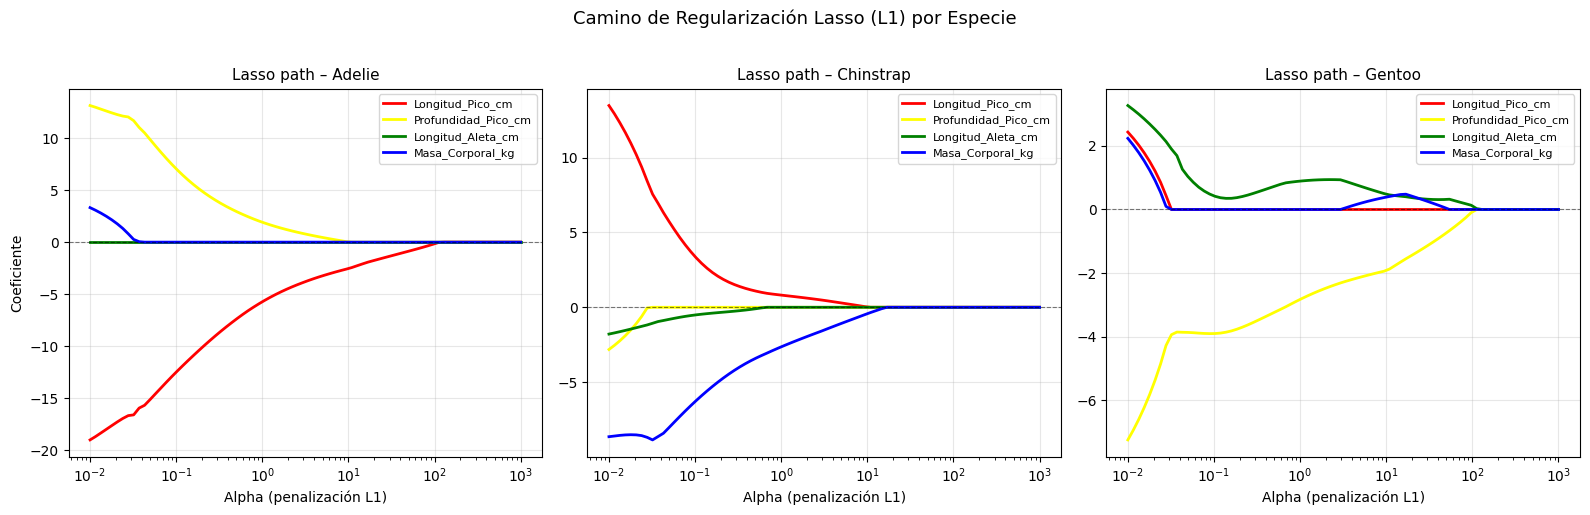

In [9]:
# 3.1 Camino de Regularización Lasso

print("*"*40)
print("  3.1 Camino de Regularización Lasso")
print("*"*40)

Cs_path  = np.logspace(2, -3, 80) #80 valores de C, donde cuando es grande está poco regularizado
n_clases = len(clases) #Especies a clasificar
colores = ["red", "yellow", "green", "blue"]

#Gráficos
fig, axes = plt.subplots(1, n_clases, figsize=(16, 5), sharey=False)

for idx, especie in enumerate(clases):
    coefs_path = [] #Almacenador de coeficintes obetenidos para todos los valores de C

#Recorre cada uno de los 80 niveles de regularización, por cada valor C se entrena un nuevo modelo Lasso
    for C in Cs_path:
        m = LogisticRegression(
            penalty="l1", solver="saga", C=C,
            max_iter=5000, random_state=42
        )
        m.fit(X_train_sc, y_train)
        coefs_path.append(m.coef_[idx]) #Coeficientes obtenidos para cada variable

    coefs_path = np.array(coefs_path) #Transforma a una matriz de forma (80, 4) que son 80 niveles de regularización y 4 variables predictoras
    alphas_path = 1 / Cs_path #Convertimos C en alpha para el eje ya que es la propia penalización

  #Graficar cada variable
    ax = axes[idx]
    for j, feat in enumerate(FEATURES):
        ax.plot(alphas_path, coefs_path[:, j],
                label=feat, color=colores[j], linewidth=2)

    ax.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.set_xscale("log")
    ax.set_xlabel("Alpha (penalización L1)", fontsize=10)
    ax.set_ylabel("Coeficiente" if idx == 0 else "", fontsize=10)
    ax.set_title(f"Lasso path – {especie}", fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Camino de Regularización Lasso (L1) por Especie",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("3.1_CaminoLasso.png", dpi=150)
plt.show()
plt.close()

De las gráficas podemos concluir que el comportamiento de los coeficientes frente al aumento de **α** muestra cómo Lasso va eliminando variables a medida que la penalización crece, algunos coeficientes se reducen exactamente a cero, lo que implica una selección automática de características.

A continuación, las carácterísticas morfológicas más importantes por especie según el modelo son:

*   Para los pingüinos Adelie la longitud y profundidad del pico son las variables más persistentes.

*   En pingüinos Chinstrap la longitud del pico se mantiene como la variable dominante, mientras que masa corporal y aleta tienden a perder importancia con mayor regularización.

*   Los pingüinos Gentoo, la longitud de la aleta y la masa corporal se sostienen más tiempo, reflejando que son rasgos clave de esta especie, mientras que la profundidad del pico se atenúa rápidamente.

El gráfico evidencia que Lasso logra un modelo predictivo bueno y simplifica la interpretación al eliminar variables menos útiles, destacando las **características morfológicas más representativas de cada especie de pingüino**.

## Modelo Ridge (L2)

Ridge es una variante de la Regresión Logística que incorpora una regularización, su objetivo principal es evitar que algunos coeficientes del modelo se vuelvan demasiado grandes, ya que coeficientes muy elevados pueden hacer que el modelo se ajuste excesivamente a los datos de entrenamiento y pierda capacidad para generalizar sobre nuevos datos.

La regularización L2 añade un término de penalización proporcional al cuadrado de la magnitud de los coeficientes, forzando a que sean pequeños pero no necesariamente cero. En lugar de buscar únicamente la mejor clasificación posible, el algoritmo también intenta mantener los coeficientes en valores moderados. De esta manera se obtiene un modelo más estable y menos sensible a pequeñas variaciones en los datos.

In [10]:
# 4. Ridge (L2)

print("*"*20)
print("  4. Ridge (L2)")
print("*"*20)

alphas = np.logspace(-3, 3, 50) #controlan la intensidad de la regularización: valores pequeños aplican poca penalización y valores grandes aplican una penalización más fuerte.
best_a_ridge, best_sc_ridge = None, 0 #Almacena el mejor puntaje de desempeño arrancando en 0

#Búsqueda del mejor alpha con validación cruzada
for a in alphas:
    C = 1 / a
    sc = cross_val_score(
        LogisticRegression(
            penalty="l2",
            C=C,
            solver="lbfgs",
            max_iter=5000
        ),
        X_train_sc,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()

    if sc > best_sc_ridge:
        best_sc_ridge = sc
        best_a_ridge = a


#Entrenamiento final con el mejor alpha
ridge_clf = LogisticRegression(
            penalty="l2",
            C=1/best_a_ridge,
            solver="lbfgs",
            max_iter=5000
        )
ridge_clf.fit(X_train_sc, y_train)

y_pred_ridge = ridge_clf.predict(X_test_sc) #Genera las predicciones del modelo Ridge entrenado sobre el conjunto de prueba.
acc_ridge = accuracy_score(y_test, y_pred_ridge)
f1_ridge  = f1_score(y_test, y_pred_ridge, average="macro")
recall_ridge = recall_score(y_test, y_pred_ridge, average="macro") #Sensibilidad promedio por clase
support_ridge = pd.Series(y_test).value_counts().reindex(range(len(clases))).values #Cantidad real de obs. por clase en test

#Evaluación de modelo
print("/n")
print(f"Mejor valor alpha: {best_a_ridge:.4f}")
print(f"Accuracy Ridge: {acc_ridge:.4f}")
print(f"F1-macro Ridge: {f1_ridge:.4f}")
print(f"Recall-macro Ridge: {recall_ridge:.4f}")
print(f"Support por clase Ridge: {dict(zip(clases, support_ridge))}")
print(f"Accuracy (CV-5): {best_sc_ridge:.4f}")

#Coeficientes
print("\n")
print("Coeficientes Ridge por especie:")
print(pd.DataFrame(ridge_clf.coef_, columns=FEATURES, index=clases).round(3).to_string())


********************
  4. Ridge (L2)
********************
/n
Mejor valor alpha: 0.0072
Accuracy Ridge: 1.0000
F1-macro Ridge: 1.0000
Recall-macro Ridge: 1.0000
Support por clase Ridge: {'Adelie': np.int64(30), 'Chinstrap': np.int64(14), 'Gentoo': np.int64(25)}
Accuracy (CV-5): 0.9891


Coeficientes Ridge por especie:
           Longitud_Pico_cm  Profundidad_Pico_cm  Longitud_Aleta_cm  Masa_Corporal_kg
Adelie              -10.721                7.397             -1.125             2.589
Chinstrap             9.092               -1.881             -1.932            -5.075
Gentoo                1.629               -5.516              3.058             2.486


La aplicación de Ridge (L2) mostró un rendimiento impecable en la clasificación de las especies de pingüinos, alcanzando un accuracy y un F1-macro de **1** en el conjunto de prueba. La validación cruzada de **98.91%**, confirma que generaliza muy bien y no está sobreajustado. El mejor valor de regularización fue **α = 0.0072**, lo que indica que una penalización baja, bastó para estabilizar los coeficientes sin perder capacidad predictiva.

Los coeficientes del modelo concluye los mismo en los patrones morfológicos de los pingüinos que el modelo de Regresión Logística base: los pingüinos Adelie se distinguen por picos más profundos y menos largos, los Chinstrap por picos más largos y menor masa corporal, y los Gentoo por aletas más largas y mayor peso.

Este modelo a parte de tener un gran desempeño, también aporta estabilidad y reduce el riesgo de sobreajuste, consolidándose como una alternativa robusta e interpretativa para problemas de clasificación multiclase.

********************************************************************************
  Matrices de Confusión – Regresión Logística, Lasso (L1) y Ridge (L2)
********************************************************************************


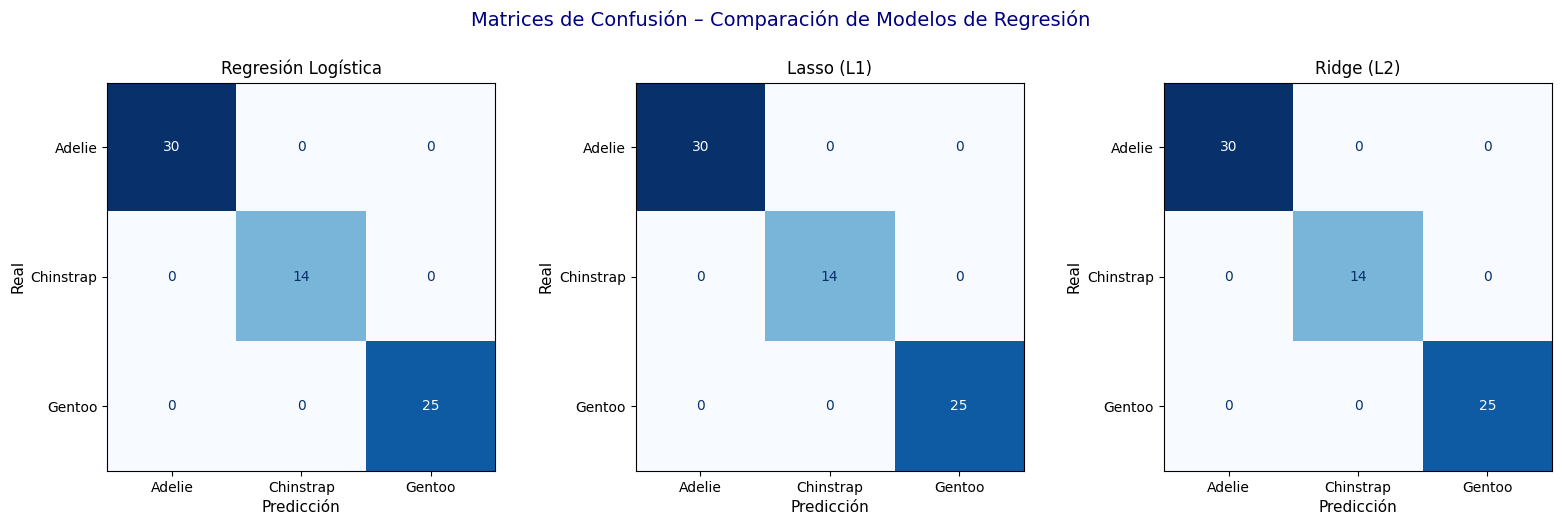

In [11]:
# Matrices de Confusión – Regresión Logística, Lasso y Ridge

print("*"*80)
print("  Matrices de Confusión – Regresión Logística, Lasso (L1) y Ridge (L2)")
print("*"*80)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos_cm = {
    "Regresión Logística": (y_pred_lr,    lr),
    "Lasso (L1)":          (y_pred_lasso, lasso_clf),
    "Ridge (L2)":          (y_pred_ridge, ridge_clf),
}

for ax, (nombre, (y_pred, _)) in zip(axes, modelos_cm.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=clases,
        ax=ax,
        colorbar=False,
        cmap="Blues"
    )
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real", fontsize=11)

plt.suptitle("Matrices de Confusión – Comparación de Modelos de Regresión", fontsize=14, y=1.02, color="navy")
plt.tight_layout()
plt.savefig("04_MatricesdeConfusión.png", dpi=150)
plt.show()
plt.close()

En las tres matrices de confusión (Regresión Logística, Lasso y Ridge) clasificaron perfectamente todas las observaciones de las especies de pingüinos, cada ejemplar de Adelie, Chinstrap y Gentoo fue identificado sin errores, lo que significa que **las variables morfológicas utilizadas contienen suficiente información para distinguir claramente entre las especies**. En consecuencia, los tres modelos presentan un desempeño excelente y confirman que el conjunto de datos es altamente informativo para tareas de clasificación, sin embargo, cada uno aporta un matiz distinto en cómo manejar la complejidad y la interpretabilidad del problema.

## MSE vs MAE - Funciones de Pérdida

Los modelos de regresión OLS y regresión por cuantiles son dos enfoques que ajustan una recta a los datos minimizando distintas funciones de pérdida: el primero minimiza el **Error Cuadrático Medio (MSE)** y el segundo el **Error Absoluto Medio (MAE)**. Su objetivo es mostrar que esta elección no solo cambia cómo se evalúa el modelo, sino también qué aprende: cuando se minimiza el MSE, el valor óptimo que se obtiene corresponde a la *media*, lo que explica por qué la regresión por mínimos cuadrados ordinarios (OLS) estima la media condicional de la variable dependiente dado el conjunto de predictores. En contraste, al minimizar el MAE, el valor que se obtiene es la *mediana*, razón por la cual la regresión por cuantiles con cuantil 0.5 estima la mediana condicional.

Como el MSE penaliza los errores al cuadrado, es mucho más sensible a valores extremos que el MAE, que los penaliza de forma lineal. Para probar esto, se utilizará la relación entre la *longitud de la aleta* y la *masa corporal* de los pingüinos, inyectándoles outliers artificiales en los datos y compararemos ambos modelos en términos de sus predicciones, métricas de error y residuos.

****************************************
  5. MSE vs MAE – Funciones de pérdida
****************************************


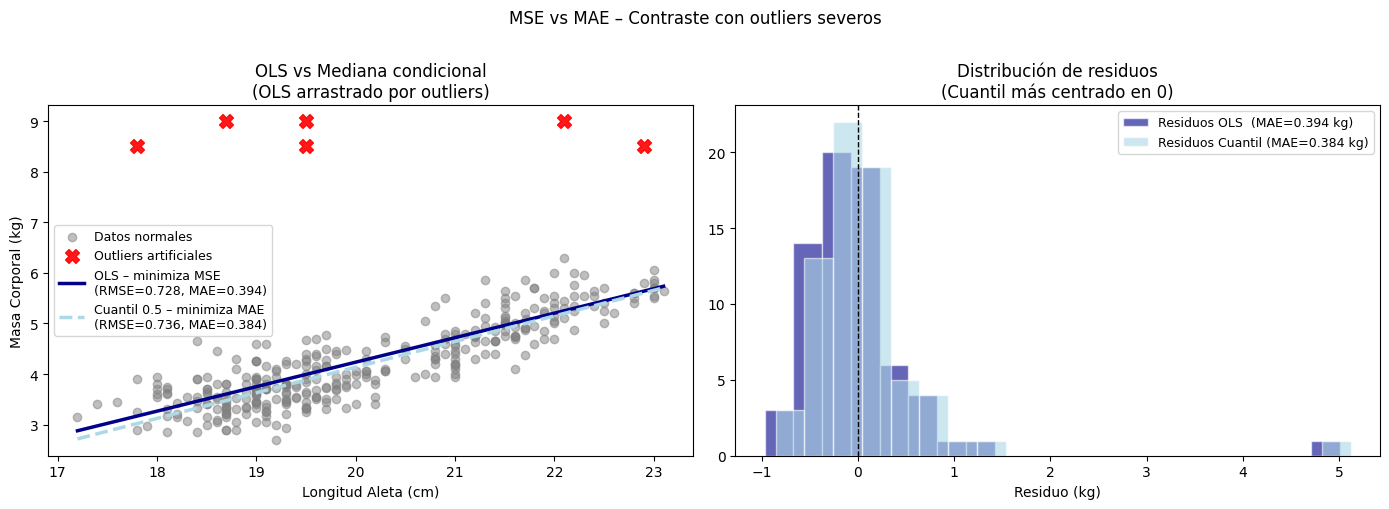

In [12]:
# 5. MSE vs MAE – Funciones de pérdida
# Error Cuadrático Medio (MSE)
# Error Absoluto Medio (MAE)

print("*"*40)
print("  5. MSE vs MAE – Funciones de pérdida")
print("*"*40)

from sklearn.linear_model import QuantileRegressor #Modelo de regresón por cuantiles

X_s = pinwinos[["Longitud_Aleta_cm"]].values #Variable predictora
y_s = pinwinos["Masa_Corporal_kg"].values.copy() #Variable a predecir

#Inyección de outliers
rng = np.random.default_rng(42) #Semilla

#Selección de 6 pingüinos y le asignamos masas corporales extremistas
idx_out = rng.choice(len(y_s), size=6, replace=False)
y_s[idx_out] = rng.choice([0.3, 0.4, 8.5, 9.0], size=6)

#Datos de entrenamiento y prueba
Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42 #80% de entrenamiento
)

#Modelo 1: Minimiza MSE (OLS / media condicional) - Mínimos Cuadrados Ordinarios
lr_mse = LinearRegression() #Minimiza la suma de errores al cuadrado
lr_mse.fit(Xtr_s, ytr_s)
y_hat_mse = lr_mse.predict(Xte_s)

#Modelo 2: Minimiza MAE (mediana condicional via regresión por cuantiles)
lr_mae = QuantileRegressor(quantile=0.5, alpha=0) #Minimiza la suma de errores absolutos
lr_mae.fit(Xtr_s, ytr_s)
y_hat_mae = lr_mae.predict(Xte_s)

#Evaluación modelo OLS
mse_mse_model = mean_squared_error(yte_s, y_hat_mse) #Error Promedio al Cuadrado
mae_mse_model = mean_absolute_error(yte_s, y_hat_mse) #Error Promedio Absoluto
rmse_mse_model = np.sqrt(mse_mse_model) #Raíz del Error Cuadrático Medio

#Evaluación modelo MAE
mse_mae_model = mean_squared_error(yte_s, y_hat_mae) #Error Promedio al Cuadrado
mae_mae_model = mean_absolute_error(yte_s, y_hat_mae) #Error Promedio Absoluto
rmse_mae_model = np.sqrt(mse_mae_model) #Raíz del Error Cuadrático Medio

#Gráficos
x_plot_s = np.linspace(X_s.min(), X_s.max(), 200).reshape(-1, 1) #Obtiene 200 valores igualmente espaciados entre el mínimo y el máximo de la longitud de aleta
y_line_mse = lr_mse.predict(x_plot_s) #Recta OLS
y_line_mae = lr_mae.predict(x_plot_s) #Recta MAE

# Separar outliers del resto para visualización
mask_out = np.zeros(len(y_s), dtype=bool) #Vector de booleanos
mask_out[idx_out] = True #6 pingüinos randoms

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Rectas ajustadas
axes[0].scatter(X_s[~mask_out], y_s[~mask_out], alpha=0.5, color="gray",
                label="Datos normales", zorder=1)
axes[0].scatter(X_s[mask_out], y_s[mask_out], alpha=0.9, color="red",
                marker="X", s=100, label="Outliers artificiales", zorder=2)
axes[0].plot(x_plot_s, y_line_mse, color="darkblue", linewidth=2.5,
             label=f"OLS – minimiza MSE\n(RMSE={rmse_mse_model:.3f}, MAE={mae_mse_model:.3f})")
axes[0].plot(x_plot_s, y_line_mae, color="lightblue", linewidth=2.5, linestyle="--",
             label=f"Cuantil 0.5 – minimiza MAE\n(RMSE={rmse_mae_model:.3f}, MAE={mae_mae_model:.3f})")
axes[0].set_xlabel("Longitud Aleta (cm)")
axes[0].set_ylabel("Masa Corporal (kg)")
axes[0].set_title("OLS vs Mediana condicional\n(OLS arrastrado por outliers)")
axes[0].legend(fontsize=9)

#Errores (residuos)
res_mse = yte_s - y_hat_mse #Residuos de OLS
res_mae = yte_s - y_hat_mae #Residuo para el QuatileRegressor
axes[1].hist(res_mse, bins=20, alpha=0.6, color="darkblue", edgecolor="white",
             label=f"Residuos OLS  (MAE={mae_mse_model:.3f} kg)")
axes[1].hist(res_mae, bins=20, alpha=0.6, color="lightblue", edgecolor="white",
             label=f"Residuos Cuantil (MAE={mae_mae_model:.3f} kg)")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residuo (kg)")
axes[1].set_title("Distribución de residuos\n(Cuantil más centrado en 0)")
axes[1].legend(fontsize=9)

plt.suptitle("MSE vs MAE – Contraste con outliers severos",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("05_MSE_vs_MAE.png", dpi=150)
plt.show()
plt.close()

La comparación entre OLS (MSE) y la regresión cuantil (MAE) muestra que la función de pérdida influye directamente en la sensibilidad del modelo a los valores atípicos. Debido a que MSE penaliza los errores grandes de forma cuadrática, la recta OLS se ve más afectada por los outliers y se desplaza ligeramente hacia ellos. En cambio, el modelo basado en MAE resulta más robusto, manteniendo un ajuste más representativo de la mayoría de los datos. Esto se refleja en las métricas obtenidas: OLS presenta un RMSE ligeramente menor (0.728 kg), mientras que la regresión cuantil logra un MAE más bajo (0.384 kg). En conjunto, los resultados confirman que MSE es más sensible a observaciones extremas, mientras que MAE ofrece un comportamiento más estable cuando existen outliers en el conjunto de datos

## Modelo Lineal Generalizado (GLM)

Los Modelos Lineales Generalizados (GLM) ofrecen un marco flexible que extiende la regresión lineal para manejar distintos tipos de variables respuesta. Dependiendo de la distribución elegida y de la función de enlace, un GLM puede servir tanto para predecir valores continuos como para clasificar categorías, permite evaluar la relevancia estadística de las variables explicativas. En este trabajo se mostrarán dos aplicaciones: un modelo gaussiano para estimar la masa corporal de los pingüinos y un modelo binomial para identificar si un ejemplar pertenece a la especie Gentoo

In [13]:
# 6. GLM – Modelos Lineales Generalizados

print("*"*40)
print("  6. GLM – Modelos Lineales Generalizados")
print("*"*40)

from sklearn.metrics import r2_score

#Variables predictoras
X_glm = sm.add_constant(
    pinwinos[["Longitud_Pico_cm", "Profundidad_Pico_cm", "Longitud_Aleta_cm"]]
)
y_masa = pinwinos["Masa_Corporal_kg"].values
y_bin = (pinwinos["Especie"] == "Gentoo").astype(int).values  # Gentoo = 1

Xg_train, Xg_test, ym_train, ym_test, yb_train, yb_test = train_test_split(
    X_glm, y_masa, y_bin,
    test_size=0.20, random_state=42, stratify=y_bin
)
print(f"Train: {len(Xg_train)} | Test: {len(Xg_test)}\n")

# 6a. Gaussiano: predice Masa_Corporal_kg
print("6a. GLM Gaussiano (Masa_Corporal_kg)")
res_gauss = sm.GLM(ym_train, Xg_train, family=sm.families.Gaussian()).fit()
print(res_gauss.summary2().tables[1].round(4))
print("Variables significativas (p < 0.05):")
for col, pval in zip(Xg_train.columns, res_gauss.pvalues):
    sig = "✅" if pval < 0.05 else "❌"
    print(f"    {sig} {col:25s}: p={pval:.4f}")

#Evaluación predictiva en test
y_pred_masa = res_gauss.predict(Xg_test)
mse_glm  = mean_squared_error(ym_test, y_pred_masa)
mae_glm  = mean_absolute_error(ym_test, y_pred_masa)
rmse_glm = np.sqrt(mse_glm)
r2_glm   = r2_score(ym_test, y_pred_masa)

print("\nDesempeño predictivo en test:")
print(f"    MSE  : {mse_glm:.4f}")
print(f"    RMSE : {rmse_glm:.4f}")
print(f"    MAE  : {mae_glm:.4f}")
print(f"    R²   : {r2_glm:.4f}")
print("\n")

# 6b. Binomial: clasifica Gentoo vs resto
print("6b. GLM Binomial (Gentoo vs resto)")
res_binom = sm.GLM(yb_train, Xg_train, family=sm.families.Binomial()).fit()
print(res_binom.summary2().tables[1].round(4))
print("\n  Variables significativas (p < 0.05):")
for col, pval in zip(Xg_train.columns, res_binom.pvalues):
    sig = "✅" if pval < 0.05 else "❌"
    print(f"    {sig} {col:25s}: p={pval:.4f}")

#Evaluación predictiva en test
y_prob_bin = res_binom.predict(Xg_test)
y_pred_bin = (y_prob_bin >= 0.5).astype(int)
acc_glm_bin = accuracy_score(yb_test, y_pred_bin)
f1_glm_bin  = f1_score(yb_test, y_pred_bin)
recall_glm_bin = recall_score(yb_test, y_pred_bin) #Sensibilidad (clase Gentoo=1)
support_glm_bin = pd.Series(yb_test).value_counts().sort_index().values #Cantidad real de obs. por clase en test

print("\nDesempeño predictivo en test:")
print(f"    Accuracy : {acc_glm_bin:.4f}")
print(f"    F1-score : {f1_glm_bin:.4f}")
print(f"    Recall   : {recall_glm_bin:.4f}")
print(f"    Support  : {dict(zip(['No-Gentoo','Gentoo'], support_glm_bin))}")

****************************************
  6. GLM – Modelos Lineales Generalizados
****************************************
Train: 275 | Test: 69

6a. GLM Gaussiano (Masa_Corporal_kg)
                      Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const               -6.3396    0.6334 -10.0088  0.0000 -7.5810 -5.0981
Longitud_Pico_cm     0.0393    0.0607   0.6484  0.5167 -0.0796  0.1582
Profundidad_Pico_cm  0.2225    0.1512   1.4716  0.1411 -0.0738  0.5189
Longitud_Aleta_cm    0.4972    0.0284  17.4851  0.0000  0.4415  0.5529
Variables significativas (p < 0.05):
    ✅ const                    : p=0.0000
    ❌ Longitud_Pico_cm         : p=0.5167
    ❌ Profundidad_Pico_cm      : p=0.1411
    ✅ Longitud_Aleta_cm        : p=0.0000

Desempeño predictivo en test:
    MSE  : 0.1607
    RMSE : 0.4009
    MAE  : 0.3197
    R²   : 0.7778


6b. GLM Binomial (Gentoo vs resto)
                        Coef.     Std.Err.       z   P>|z|       [0.025  \
const               -300.7283  405371.898

En el modelo Gaussiano para predecir la masa corporal, evaluado sobre el 20% de datos de prueba, la variable Longitud_Aleta_cm resultó la única estadísticamente significativa (p < 0.05), mientras que Longitud_Pico_cm y Profundidad_Pico_cm no mostraron evidencia suficiente de asociación una vez consideradas conjuntamente en el modelo. Esto confirma que la longitud de la aleta es el principal predictor de la masa corporal dentro de las variables analizadas. El desempeño fuera de muestra respalda esta conclusión: el modelo explica el 77.78% de la varianza en el conjunto de prueba (R² = 0.778), con un error promedio de 0.32 kg (MAE) y una raíz del error cuadrático medio de 0.40 kg (RMSE), un margen razonable si se considera que la masa corporal en el dataset va de 2.7 a 6.3 kg.

Para el modelo binomial, los resultados muestran coeficientes y errores estándar extremadamente grandes, acompañados de valores p cercanos a 1 con el 80% de los datos de entrenamiento. Esto confirma la presencia de separación casi perfecta entre la especie Gentoo y las demás especies utilizando las variables morfológicas seleccionadas. En estas condiciones, el proceso de estimación por máxima verosimilitud se vuelve inestable, por lo que los coeficientes obtenidos y sus pruebas de significancia estadística no pueden interpretarse de manera confiable. Sin embargo, la evaluación fuera de muestra es contundente: el modelo clasificó correctamente el 100% de las observaciones del conjunto de prueba (Accuracy = F1-score = **1**), confirmando que, más allá de la inestabilidad estadística de los coeficientes, las variables incluidas poseen una **alta capacidad** para distinguir individuos Gentoo del resto de especies.

## Modelos LDA y QDA

Antes de entrenar los modelos LDA y QDA, las variables categóricas fueron transformadas a formato numérico mediante Label Encoding. Posteriormente, las variables predictoras fueron estandarizadas para colocarlas en una escala comparable y evitar que diferencias de magnitud influyeran en el proceso de clasificación. Finalmente, la base fue dividida en conjuntos de entrenamiento y prueba utilizando una partición estratificada 80/20, preservando la proporción original de especies en ambos conjuntos.

In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pinwinos.copy()

# Copia para no modificar el df original
df_modelo = df.copy()

# Codificar Sexo porque LDA/QDA necesitan variables numéricas
le_sexo = LabelEncoder()
df_modelo["Sexo_cod"] = le_sexo.fit_transform(df_modelo["Sexo"])

# Variables predictoras: medidas corporales + año + sexo
variables_A = [
    "Longitud_Pico_cm",
    "Profundidad_Pico_cm",
    "Longitud_Aleta_cm",
    "Masa_Corporal_kg",
    "Anio",
    "Sexo_cod"
]

X_A = df_modelo[variables_A].copy()

# Variable objetivo: especie
le = LabelEncoder()
y = le.fit_transform(df_modelo["Especie"])

print("Clases de especie:")
print(le.classes_)

print("Clases de sexo:")
print(le_sexo.classes_)

# Escalamiento
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

# División train/test 80/20 estratificada
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train_A.shape)
print("Test:", X_test_A.shape)

Clases de especie:
['Adelie' 'Chinstrap' 'Gentoo']
Clases de sexo:
['Hembra' 'Macho']
Train: (275, 6)
Test: (69, 6)


## Resultados de la partición

La partición generó un conjunto de entrenamiento con 275 observaciones y un conjunto de prueba con 69 observaciones. La utilización de estratificación permitió conservar la distribución relativa de las especies, garantizando que tanto el entrenamiento como la evaluación del modelo se realizaran sobre muestras representativas de la población original.

In [15]:
pd.Series(y_train_A).value_counts(normalize=True)

,proportion
0,0.443636
2,0.360000
1,0.196364


In [16]:
pd.Series(y_test_A).value_counts(normalize=True)

,proportion
0,0.434783
2,0.362319
1,0.202899


## Evaluación del supuesto de normalidad

Dado que LDA y QDA se fundamentan en supuestos estadísticos relacionados con la distribución de las variables, se aplicó la prueba de Shapiro-Wilk sobre las variables morfológicas continuas. El objetivo fue evaluar si dichas variables presentan un comportamiento compatible con una distribución normal.

In [17]:
from scipy.stats import shapiro

# Solo variables continuas
variables_normalidad = [
    "Longitud_Pico_cm",
    "Profundidad_Pico_cm",
    "Longitud_Aleta_cm",
    "Masa_Corporal_kg"
]

for variable in variables_normalidad:

    stat, p = shapiro(df[variable])

    print(variable)
    print(f"p-value = {p:.5f}")

    if p > 0.05:
        print("No se rechaza normalidad\n")
    else:
        print("Se rechaza normalidad\n")

Longitud_Pico_cm
p-value = 0.00001
Se rechaza normalidad

Profundidad_Pico_cm
p-value = 0.00000
Se rechaza normalidad

Longitud_Aleta_cm
p-value = 0.00000
Se rechaza normalidad

Masa_Corporal_kg
p-value = 0.00000
Se rechaza normalidad



### Resultados de la prueba de normalidad

Para todas las variables analizadas se obtuvieron valores p inferiores a 0.05, por lo que se rechazó la hipótesis de normalidad. Esto indica que las distribuciones observadas difieren de una distribución normal teórica.

No obstante, se decidió continuar con la aplicación de LDA y QDA debido a que estos métodos suelen mostrar un buen desempeño incluso cuando los supuestos no se cumplen estrictamente, especialmente en conjuntos de datos con un tamaño de muestra moderado y una separación clara entre clases. Además, el objetivo principal del proyecto es evaluar empíricamente la capacidad de clasificación de ambos modelos sobre las especies de pingüinos.

## Modelo LDA

El Análisis Discriminante Lineal (LDA) fue utilizado como primer modelo de clasificación. Este método busca encontrar combinaciones lineales de las variables predictoras que maximicen la separación entre las especies, asumiendo que todas las clases comparten una misma matriz de covarianza. Debido a su simplicidad e interpretabilidad, LDA suele ser una referencia importante en problemas de clasificación multiclase.

In [18]:
# 7. LDA

print("*"*20)
print("  7. LDA")
print("*"*20)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()

lda.fit(X_train_A, y_train_A)

y_pred_lda = lda.predict(X_test_A)

print("Modelo entrenado")

********************
  7. LDA
********************
Modelo entrenado


In [19]:
#Evaluación LDA

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    classification_report
)

print("Accuracy:",
      round(accuracy_score(y_test_A,y_pred_lda),4))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test_A,y_pred_lda),4))

print("Precision Macro:",
      round(precision_score(y_test_A,y_pred_lda,
                           average="macro"),4))

print("Recall Macro:",
      round(recall_score(y_test_A,y_pred_lda,
                        average="macro"),4))

print("F1 Macro:",
      round(f1_score(y_test_A,y_pred_lda,
                    average="macro"),4))

print("Kappa:",
      round(cohen_kappa_score(y_test_A,y_pred_lda),4))

print("\n")

print(classification_report(
    y_test_A,
    y_pred_lda,
    target_names=le.classes_
))

Accuracy: 1.0
Balanced Accuracy: 1.0
Precision Macro: 1.0
Recall Macro: 1.0
F1 Macro: 1.0
Kappa: 1.0


              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



### Resultados de LDA

El modelo LDA obtuvo un desempeño perfecto sobre el conjunto de prueba, alcanzando valores de 1.00 en Accuracy, Balanced Accuracy, Precision, Recall, F1-Score y Kappa. Esto indica que todas las observaciones fueron clasificadas correctamente y que el modelo logró distinguir sin errores las tres especies de pingüinos presentes en la base de datos.

Los resultados sugieren que las variables morfológicas seleccionadas contienen suficiente información para separar claramente las especies, permitiendo que una frontera de decisión lineal sea suficiente para resolver el problema de clasificación.

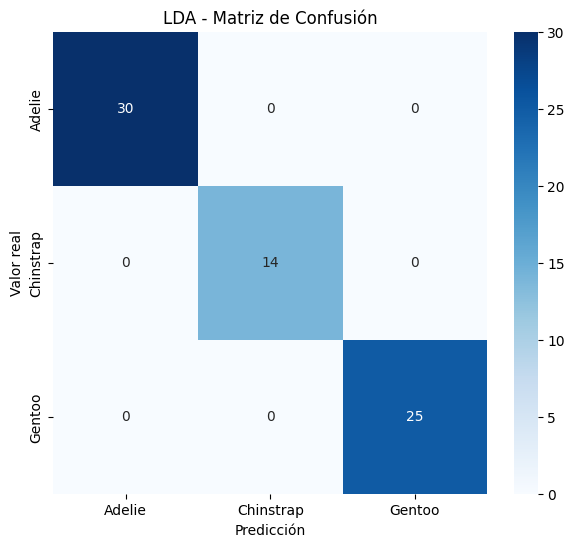

In [20]:
#Matriz de Confusión LDA

cm = confusion_matrix(y_test_A,y_pred_lda)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("LDA - Matriz de Confusión")

plt.show()

La matriz de confusión confirma el desempeño observado en las métricas anteriores. Todas las observaciones fueron clasificadas en su especie correcta, por lo que no se registraron errores de clasificación entre Adelie, Chinstrap y Gentoo.

La ausencia de elementos fuera de la diagonal principal indica que el modelo logró una separación completa entre las tres clases utilizando únicamente las variables consideradas en el análisis.

In [21]:
# Validación cruzada
scores = cross_val_score(
    lda,
    X_A_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

print("Accuracies por fold:")
print(scores)

print("\nAccuracy promedio:")
print(scores.mean())

print("\nDesviación estándar:")
print(scores.std())

Accuracies por fold:
[1.         1.         0.98550725 0.98550725 1.        ]

Accuracy promedio:
0.9942028985507246

Desviación estándar:
0.007099970268936725


Con el objetivo de evaluar la estabilidad del modelo, se aplicó validación cruzada. Los resultados muestran una exactitud promedio cercana al 99.42%, con una variabilidad muy reducida entre particiones.

Esto indica que el excelente desempeño observado en el conjunto de prueba no depende de una única división de los datos, sino que se mantiene de forma consistente en diferentes subconjuntos de entrenamiento y validación. Por lo tanto, el modelo LDA presenta una alta capacidad de generalización para este conjunto de datos.

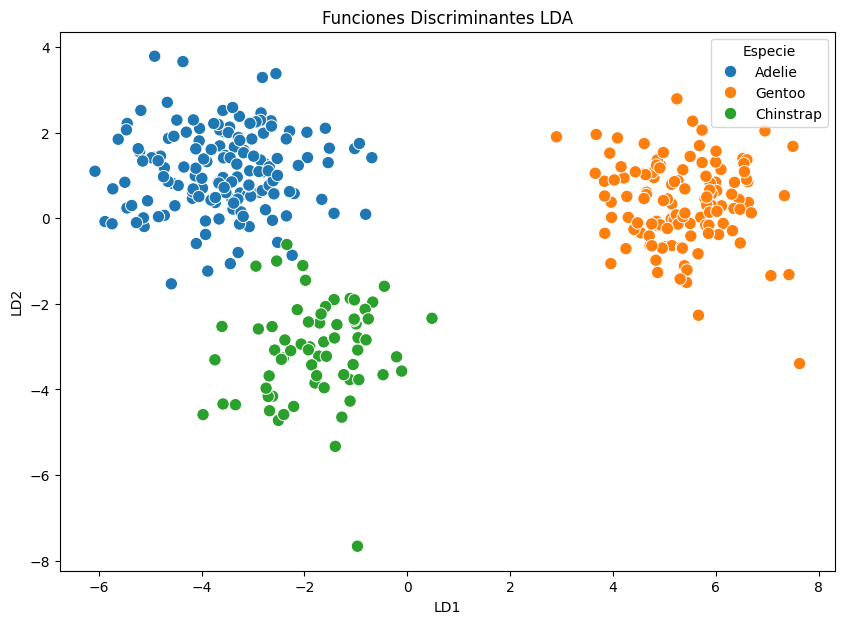

In [22]:
#Gráfico Funciones Discriminantes LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_viz = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda_viz.fit_transform(X_A_scaled, y)

lda_df = pd.DataFrame({
    "LD1": X_lda[:,0],
    "LD2": X_lda[:,1],
    "Especie": le.inverse_transform(y)
})

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=lda_df,
    x="LD1",
    y="LD2",
    hue="Especie",
    s=80
)

plt.title("Funciones Discriminantes LDA")
plt.show()

## Modelo QDA

El Análisis Discriminante Cuadrático (QDA) es una extensión de LDA que permite que cada clase tenga su propia matriz de covarianza. Esto genera fronteras de decisión cuadráticas y proporciona mayor flexibilidad para modelar relaciones complejas entre las variables predictoras. Sin embargo, esta flexibilidad también puede incrementar la sensibilidad al ruido y al tamaño de la muestra, por lo que resulta interesante comparar su desempeño frente al modelo LDA.

In [23]:
# 7. QDA

print("*"*20)
print("  7. QDA")
print("*"*20)

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train_A, y_train_A)

y_pred_qda = qda.predict(X_test_A)

print("Modelo QDA entrenado")

********************
  7. QDA
********************
Modelo QDA entrenado


In [24]:
#Evaluación QDA

print("Accuracy:",
      round(accuracy_score(y_test_A,y_pred_qda),4))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test_A,y_pred_qda),4))

print("Precision Macro:",
      round(precision_score(y_test_A,y_pred_qda,
                           average="macro"),4))

print("Recall Macro:",
      round(recall_score(y_test_A,y_pred_qda,
                        average="macro"),4))

print("F1 Macro:",
      round(f1_score(y_test_A,y_pred_qda,
                    average="macro"),4))

print("Kappa:",
      round(cohen_kappa_score(y_test_A,y_pred_qda),4))

print("\n")

print(classification_report(
    y_test_A,
    y_pred_qda,
    target_names=le.classes_
))

Accuracy: 0.9855
Balanced Accuracy: 0.9889
Precision Macro: 0.9778
Recall Macro: 0.9889
F1 Macro: 0.9829
Kappa: 0.9774


              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.98      0.99      0.98        69
weighted avg       0.99      0.99      0.99        69



El modelo QDA obtuvo un desempeño sobresaliente, alcanzando una exactitud del 98.55%. Asimismo, las métricas de Precision, Recall y F1-Score fueron superiores al 97%, indicando una capacidad muy alta para clasificar correctamente las especies de pingüinos.

Aunque el desempeño fue ligeramente inferior al obtenido por LDA, los resultados muestran que QDA también es capaz de capturar adecuadamente los patrones presentes en las variables morfológicas utilizadas en el estudio.

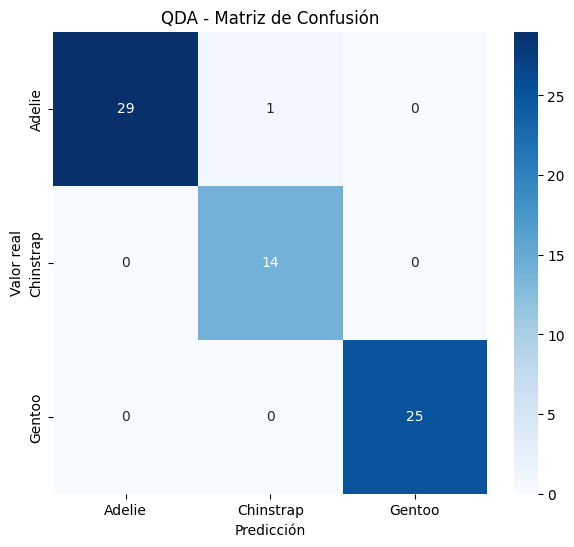

In [25]:
#Matriz de confusión QDA
cm_qda = confusion_matrix(y_test_A,y_pred_qda)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_qda,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("QDA - Matriz de Confusión")

plt.show()

La matriz de confusión muestra que únicamente se presentó un error de clasificación. En particular, un individuo de la especie Adelie fue clasificado como Chinstrap, mientras que el resto de las observaciones fueron identificadas correctamente.

Este resultado confirma que el modelo presenta una capacidad predictiva muy elevada, aunque ligeramente inferior a la observada en LDA, donde no se registraron errores de clasificación.

In [26]:
#Validación cruzada QDA
scores_qda = cross_val_score(
    qda,
    X_A_scaled,
    y,
    cv=5,
    scoring="accuracy"
)

print("Accuracies por fold:")
print(scores_qda)

print("\nAccuracy promedio:")
print(scores_qda.mean())

print("\nDesviación estándar:")
print(scores_qda.std())

Accuracies por fold:
[1.         0.98550725 0.98550725 1.         0.98529412]

Accuracy promedio:
0.9912617220801364

Desviación estándar:
0.0071351984684316664


In [27]:
print(type(lda))
print(type(qda))

<class 'sklearn.discriminant_analysis.LinearDiscriminantAnalysis'>
<class 'sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis'>


In [28]:
sum(y_pred_lda != y_pred_qda)

np.int64(1)

In [29]:
#Coeficientes
coef_df = pd.DataFrame(
    lda.coef_.T,
    index=variables_A,
    columns=le.classes_
)

coef_df

,Adelie,Chinstrap,Gentoo
Longitud_Pico_cm,-5.268337,5.736067,3.363530
Profundidad_Pico_cm,6.716363,4.449154,-10.703542
Longitud_Aleta_cm,-5.568882,-3.265167,8.643663
Masa_Corporal_kg,-2.648405,-5.071118,6.029756
Anio,1.016135,0.343862,-1.439768
Sexo_cod,1.767519,-0.572404,-1.865935


Los coeficientes estimados por LDA permiten identificar la contribución de cada variable en la separación de las especies. Debido a que el signo del coeficiente únicamente indica la dirección del efecto sobre cada clase, se utilizó el valor absoluto promedio para medir la importancia global de cada predictor.

Los resultados muestran que la Profundidad_Pico_cm es la variable con mayor capacidad discriminante, seguida por la Longitud_Aleta_cm, la Longitud_Pico_cm y la Masa_Corporal_kg. Esto indica que las diferencias morfológicas relacionadas con el tamaño del pico y las dimensiones corporales son los principales factores que permiten distinguir entre especies.

Por otro lado, las variables Año y Sexo presentan coeficientes considerablemente menores, sugiriendo que aportan poca información adicional al proceso de clasificación.

Estos hallazgos coinciden con el análisis exploratorio realizado previamente, donde las medidas corporales mostraron patrones claramente diferenciados entre Adelie, Chinstrap y Gentoo.

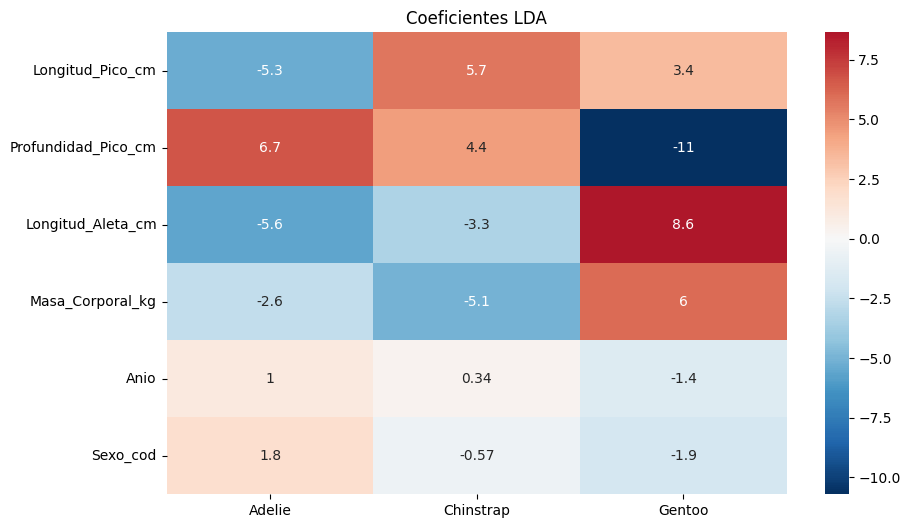

In [30]:
#Gráfico Coeficientes
plt.figure(figsize=(10,6))

sns.heatmap(
    coef_df,
    annot=True,
    cmap="RdBu_r",
    center=0
)

plt.title("Coeficientes LDA")
plt.show()

### Interpretación de los coeficientes LDA

El mapa de calor muestra los coeficientes estimados por el modelo LDA para cada especie. Valores absolutos más grandes indican una mayor contribución de la variable en la discriminación entre grupos.

Se observa que las variables con mayor influencia son la Longitud_Aleta_cm, la Profundidad_Pico_cm y la Masa_Corporal_kg, las cuales presentan los coeficientes más altos en magnitud. Esto sugiere que las diferencias en tamaño corporal y características del pico son los principales factores que permiten distinguir entre las especies de pingüinos.

Por otro lado, las variables Año y Sexo presentan coeficientes relativamente pequeños, indicando que aportan menos información al proceso de clasificación en comparación con las variables morfológicas.

Estos resultados son consistentes con el análisis exploratorio realizado previamente, donde las medidas corporales mostraron una clara separación entre especies.

In [31]:
#Coeficientes Promedio Absolutos
coef_abs = coef_df.abs()

coef_abs["Importancia_Promedio"] = coef_abs.mean(axis=1)

coef_abs = coef_abs.sort_values(
    by="Importancia_Promedio",
    ascending=False
)

coef_abs

,Adelie,Chinstrap,Gentoo,Importancia_Promedio
Profundidad_Pico_cm,6.716363,4.449154,10.703542,7.289686
Longitud_Aleta_cm,5.568882,3.265167,8.643663,5.825904
Longitud_Pico_cm,5.268337,5.736067,3.363530,4.789311
Masa_Corporal_kg,2.648405,5.071118,6.029756,4.583093
Sexo_cod,1.767519,0.572404,1.865935,1.401952
Anio,1.016135,0.343862,1.439768,0.933255


### Importancia de las variables

Los coeficientes promedio absolutos permiten identificar qué variables contribuyen más a la discriminación entre especies. Se observa que la Profundidad_Pico_cm presenta la mayor importancia promedio, seguida por la Longitud_Aleta_cm, la Longitud_Pico_cm y la Masa_Corporal_kg.

Estos resultados sugieren que las características relacionadas con el pico y el tamaño corporal contienen la mayor cantidad de información para diferenciar las especies de pingüinos. En particular, la profundidad del pico emerge como la variable más influyente dentro del modelo LDA.

Por el contrario, las variables Año y Sexo muestran una contribución considerablemente menor, indicando que aportan poca capacidad discriminante en comparación con las variables morfológicas.

En consecuencia, las medidas corporales representan los factores más relevantes para la clasificación, lo cual coincide con los patrones observados durante el análisis exploratorio y con la clara separación observada entre especies en las visualizaciones previas.

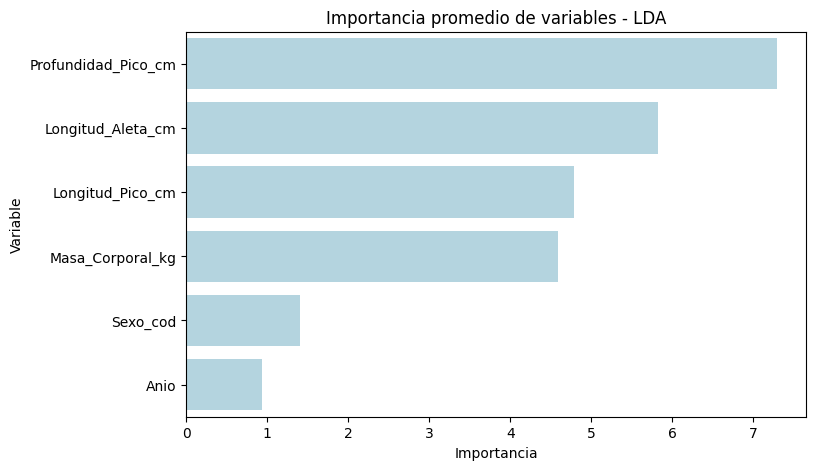

In [32]:
#Variables con mayor importancia para clasificación
plt.figure(figsize=(8,5))

sns.barplot(
    x=coef_abs["Importancia_Promedio"],
    y=coef_abs.index,
    color="lightblue"
)

plt.title("Importancia promedio de variables - LDA")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

Los coeficientes promedio absolutos permiten identificar qué variables contribuyen más a la discriminación entre especies. Se observa que la Profundidad_Pico_cm presenta la mayor importancia promedio, seguida por Longitud_Aleta_cm y Longitud_Pico_cm.

Estos resultados sugieren que las características relacionadas con el pico y el tamaño corporal contienen la mayor cantidad de información para diferenciar las especies de pingüinos. Por el contrario, las variables Año y Sexo muestran una contribución considerablemente menor, indicando que aportan poca capacidad discriminante en comparación con las variables morfológicas.

En consecuencia, las medidas corporales representan los factores más relevantes para la clasificación, lo cual coincide con los patrones observados durante el análisis exploratorio.

## Resumen entre modelos lineales

***********************************
 Comparación final de modelos
***********************************
                Modelo  Accuracy  F1-macro  Recall-macro  Support     CV-5
   Regresión Logística  1.000000  1.000000      1.000000       69 0.985455
            Ridge (L2)  1.000000  1.000000      1.000000       69 0.989091
                   LDA  1.000000  1.000000      1.000000       69 0.989091
            Lasso (L1)  1.000000  1.000000      1.000000       69 0.989091
                   QDA  0.985507  0.982856      0.988889       69 0.992727
Baseline (mayoritario)  0.434783  0.202020      0.333333       69 0.443636


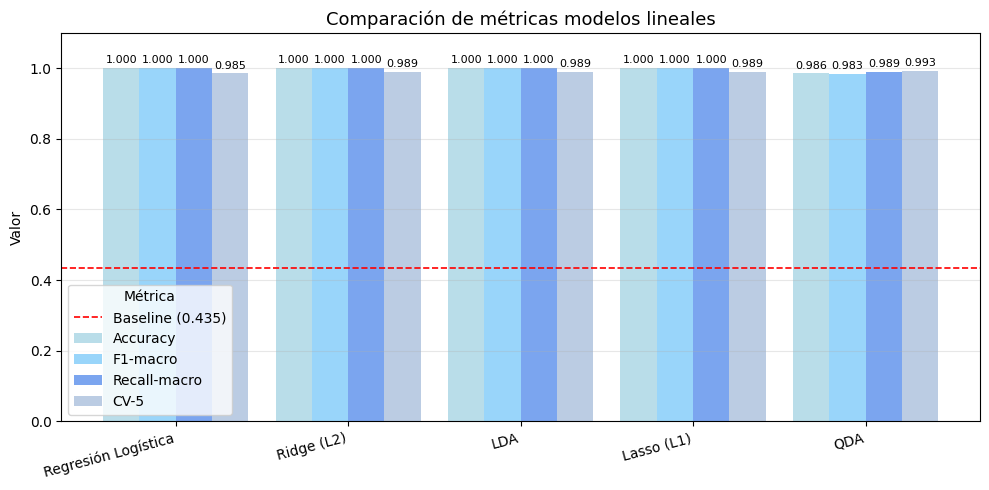

In [33]:
# 7. Comparación final de modelos
print("*"*35)
print(" Comparación final de modelos")
print("*"*35)

#Diccionario de modelos y predicciones
modelos = {
    "Baseline (mayoritario)": (y_baseline, DummyClassifier(strategy="most_frequent", random_state=42)),
    "Regresión Logística": (y_pred_lr, lr),
    "Ridge (L2)": (y_pred_ridge, ridge_clf),
    "Lasso (L1)": (y_pred_lasso, lasso_clf),
    "LDA": (y_pred_lda, lda),
    "QDA": (y_pred_qda, qda)
}

#Evaluación
resultados = []
for nombre, (y_pred, modelo) in modelos.items():
    # LDA y QDA fueron entrenados con otro split (6 variables, incluye Año y Sexo)
    if nombre in ["LDA", "QDA"]:
        y_true_ref, X_cv, y_cv = y_test_A, X_train_A, y_train_A
    else:
        y_true_ref, X_cv, y_cv = y_test, X_train_sc, y_train

    acc = accuracy_score(y_true_ref, y_pred)
    f1  = f1_score(y_true_ref, y_pred, average="macro")
    recall = recall_score(y_true_ref, y_pred, average="macro")
    support_total = len(y_true_ref)
    cv  = cross_val_score(modelo, X_cv, y_cv, cv=5,
                          scoring="accuracy").mean()
    resultados.append({"Modelo": nombre, "Accuracy": acc, "F1-macro": f1,
                        "Recall-macro": recall, "Support": support_total, "CV-5": cv})

df_res = pd.DataFrame(resultados).sort_values("Accuracy", ascending=False)
print(df_res.to_string(index=False))

#Gráfica
df_plot = df_res[df_res["Modelo"] != "Baseline (mayoritario)"]
metricas = ["Accuracy", "F1-macro", "Recall-macro", "CV-5"]
colores  = ["lightblue", "lightskyblue", "cornflowerblue", "lightsteelblue"]

n_metricas = len(metricas)
width = 0.2
group_gap = 0.95
x = np.arange(len(df_plot)) * group_gap

fig, ax = plt.subplots(figsize=(10, 5))

for i, (metrica, color) in enumerate(zip(metricas, colores)):
    offset = (i - (n_metricas - 1) / 2) * width   #Centra las 4 barras alrededor de x
    bars = ax.bar(x + offset, df_plot[metrica], width,
                  label=metrica, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)

ax.axhline(accuracy_score(y_test, y_baseline), color="red", ls="--", lw=1.2,
           label=f"Baseline ({accuracy_score(y_test, y_baseline):.3f})")

ax.set_xticks(x)
ax.set_xticklabels(df_plot["Modelo"], rotation=15, ha="right")
ax.set_ylabel("Valor")
ax.set_title("Comparación de métricas modelos lineales", fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend(title="Métrica")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("07_Comparacion_Modelos.png", dpi=150)
plt.show()